# Intro

In [ ]:
%cd /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/

/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis


In [2]:
import pandas as pd
import torch
from tqdm import tqdm

from architecture.extended_cbm import CBMWrapper, ExtendedCBMOutput, init_from_checkpoint
from cbm_datasets import Batch, get_dataloader, get_datasets


In [3]:
train_dataset_cub, val_dataset_cub, test_dataset_cub, _, _, _ = get_datasets(dataset_name='CUB_112', 
                                                        root_dir='/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets', 
                                                        img_size=256, 
                                                        use_soft_labels=False, concept_masks_scale=None,
                                                        attr_level='image')

train_loader_cub, val_loader_cub, test_loader_cub = get_dataloader(batch_size=4, num_workers=6, 
                                                       train_dataset=train_dataset_cub, val_dataset=val_dataset_cub, 
                                                       test_dataset=test_dataset_cub)

In [3]:
def create_summary_table(df: pd.DataFrame, filter_tag:list[str], reference_measure:str):
    """Erstellt eine Tabelle mit den Bestwerten pro Run."""
    print("\nErstelle Summary Tabelle (Max-Werte)...")

    # filter df for each column where df[column] is true
    for tag in filter_tag:
        col = f"tag_{tag}"
        if col not in df.columns:
            raise ValueError(f"Tag-Spalte {col} existiert nicht im DataFrame.")
        df = df[df[col] == True]

    if df.empty:
        print("DataFrame nach Tag-Filter leer.")
        return df

    # Sicherstellen, dass innerhalb jedes Runs nach step sortiert ist
    df = df.sort_values(["run_id", "_step"]).copy()

    # Epoch als laufende Evaluation pro run_id (startet bei 0)
    df["epoch"] = df.groupby("run_id").cumcount()

    # Bestes F1-Concept pro Run auswählen
    best_per_run = (
        df.loc[df.groupby("run_id")[reference_measure].idxmax()]
        .reset_index(drop=True)
    )
    
    # Speichern
    best_per_run.to_parquet("thesis-figures/extended_cbm/results/2_extended_cbm_results_best.parquet")
    print("Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet")
    return best_per_run

In [14]:
PATH = '/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/thesis-figures/extended_cbm/results/1_extended_cbm_results.parquet'

In [22]:
val_results_raw = pd.read_parquet(PATH)

In [115]:
reference_measure = "$F_1$ Concept"
# reference_measure = "Foreground-Dice"

val_results_aff = create_summary_table(val_results_raw, filter_tag=["aab-aff"], reference_measure=reference_measure).rename(columns={'Mean Dice': 'Dice'})
val_results_soft = create_summary_table(val_results_raw, filter_tag=["aab-soft-bce"], reference_measure=reference_measure).rename(columns={'Mean Dice': 'Dice'})
val_results_soft = val_results_soft[val_results_soft['run_id']=='17m6p70g']


Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet

Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet


In [116]:
val_results['run_id']

3    msu693b8
2    c0ldpb7v
1    9lexo76a
0    17m6p70g
Name: run_id, dtype: object

In [117]:
val_results = pd.concat([val_results_soft, val_results_aff])

val_results = val_results.merge(pd.DataFrame({
    'run_id': ['17m6p70g', '9lexo76a', 'c0ldpb7v', 'msu693b8'],
    'value': ['base', '0.5', '0.1', '0.01']
    
    }), on='run_id').sort_values(by='value')

In [118]:
device = 'cuda'
batch: Batch = next(iter(val_loader_cub))
batch = batch.to(device)

In [119]:
run_ids = val_results['run_id'].to_list()
epochs = val_results['epoch'].to_list()
datasets = val_results['Dataset'].to_list()
header = val_results['value'].to_list()

In [120]:
print(run_ids)

['msu693b8', 'c0ldpb7v', '9lexo76a', '17m6p70g']


In [121]:
val_results_soft_pretty = val_results[
    ['Segmentation Module', 'Concept Module', 'value', 
     'Recall-Concept', 'Precision-Concept', 
     'IoU-Mean', 'Foreground-Dice', 
     '$F_1$ Concept', 'Dice',
    'Accuracy-Concept', 'run_id', 
       ]]

In [122]:
val_results_soft_pretty

,Segmentation Module,Concept Module,value,Recall-Concept,Precision-Concept,IoU-Mean,Foreground-Dice,$F_1$ Concept,Dice,Accuracy-Concept,run_id
3,Upscaled MultiLayer,Top-K AvgPool,0.01,0.716613,0.469703,0.618927,0.179185,0.557369,0.630242,0.759614,msu693b8
2,Upscaled MultiLayer,Top-K AvgPool,0.1,0.732001,0.471014,0.626182,0.225629,0.563482,0.640232,0.762670,c0ldpb7v
1,Upscaled MultiLayer,Top-K AvgPool,0.5,0.731568,0.469698,0.634895,0.261560,0.563759,0.650366,0.763766,9lexo76a
0,Upscaled MultiLayer,Top-K AvgPool,base,0.722896,0.479520,0.599707,0.285679,0.565589,0.616629,0.765323,17m6p70g


In [123]:
l = val_results_soft_pretty.to_latex()
print(l)

\begin{tabular}{llllrrrrrrrl}
\toprule
 & Segmentation Module & Concept Module & value & Recall-Concept & Precision-Concept & IoU-Mean & Foreground-Dice & $F_1$ Concept & Dice & Accuracy-Concept & run_id \\
\midrule
3 & Upscaled MultiLayer & Top-K AvgPool & 0.01 & 0.716613 & 0.469703 & 0.618927 & 0.179185 & 0.557369 & 0.630242 & 0.759614 & msu693b8 \\
2 & Upscaled MultiLayer & Top-K AvgPool & 0.1 & 0.732001 & 0.471014 & 0.626182 & 0.225629 & 0.563482 & 0.640232 & 0.762670 & c0ldpb7v \\
1 & Upscaled MultiLayer & Top-K AvgPool & 0.5 & 0.731568 & 0.469698 & 0.634895 & 0.261560 & 0.563759 & 0.650366 & 0.763766 & 9lexo76a \\
0 & Upscaled MultiLayer & Top-K AvgPool & base & 0.722896 & 0.479520 & 0.599707 & 0.285679 & 0.565589 & 0.616629 & 0.765323 & 17m6p70g \\
\bottomrule
\end{tabular}



In [101]:
def load_and_predict(run_ids:list[str], epochs:list[int], datasets:list[str], batch:Batch,):

    predictions: list[ExtendedCBMOutput] = [] 
    for run_id, epoch, dataset in tqdm(zip(run_ids, epochs, datasets)):
    
        model = init_from_checkpoint(run_id=run_id, epoch=epoch, dataset=dataset.lower(), device=device)

        pred: ExtendedCBMOutput = model(batch.images)
        predictions.append(pred)

    return predictions

In [102]:
predictions = load_and_predict(run_ids=run_ids, epochs=epochs, datasets=datasets, batch=batch)

0it [00:00, ?it/s]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
1it [00:01,  1.87s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
2it [00:03,  1.58s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
3it [00:04,  1.50s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
4it [00:06,  1.53s/it]


In [103]:
import matplotlib.pyplot as plt


def plot_single_concept_multi_model_paper(
    predictions_list,          # Liste von Model-Predictions
    model_names,               # Liste der Modellnamen (gleiche Reihenfolge)
    concept_id,                # Zu visualisierendes Konzept
    concept_names,
    gt_vector,
    images,
    batch_idx=0,
    alpha=0.35,
    cmap="magma",
    save_path=None
):
    """
    Paper-ready Plot:
    - Eine Reihe
    - Links: Originalbild
    - Danach: Predictions mehrerer Modelle
    - GT-Aktivierung wird farblich markiert
    """

    #denomalize images
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    images = images * std + mean

    assert len(predictions_list) == len(model_names)

    image = images[batch_idx].permute(1, 2, 0).cpu().numpy()
    concept_name = concept_names[concept_id]
    is_active_gt = gt_vector[batch_idx, concept_id] == 1

    num_models = len(predictions_list)
    total_cols = num_models + 1  # +1 für Originalbild

    fig, axes = plt.subplots(
        1,
        total_cols,
        figsize=(total_cols * 3.2, 3.5)
    )

    # -----------------------
    # Originalbild
    # -----------------------
    axes[0].imshow(image)
    axes[0].set_title("Input Image", fontsize=11)
    axes[0].axis("off")

    # -----------------------
    # Modelle
    # -----------------------
    for i, (predictions, model_name) in enumerate(zip(predictions_list, model_names)):
        ax = axes[i + 1]

        logits = predictions.segmentation_module.mask_logits[batch_idx]
        mask = logits[concept_id].sigmoid().detach().cpu().numpy()

        ax.imshow(image)
        ax.imshow(mask, cmap=cmap, alpha=alpha, vmin=0, vmax=1)

        # Titel-Formatierung
        color = "green" if is_active_gt else "black"
        weight = "bold" if is_active_gt else "normal"

        ax.set_title(
            model_name,
            fontsize=10,
            color=color,
            fontweight=weight
        )

        # Rahmenfarbe
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2 if is_active_gt else 0.8)

        ax.set_xticks([])
        ax.set_yticks([])

    # -----------------------
    # Gesamttitel
    # -----------------------
    fig.suptitle(
        f"Concept: {concept_name} | GT: {'Active' if is_active_gt else 'Inactive'}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

In [104]:
import numpy as np

np.where(batch.concepts[1].cpu())

(array([  2,   8,  14,  20,  22,  35,  38,  43,  50,  51,  61,  74,  85,
         86,  89,  94,  99, 100, 111]),)

In [105]:
run_ids

['msu693b8', 'c0ldpb7v', '9lexo76a', '17m6p70g']

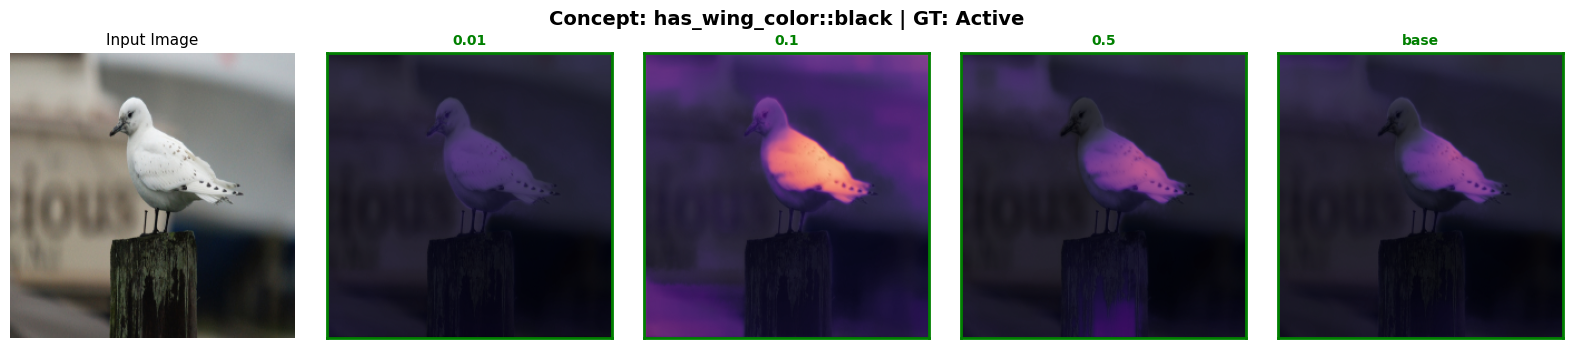

In [108]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions,
    model_names=header,
    concept_id=7,
    concept_names=train_dataset_cub.concepts.to_list(),
    gt_vector=batch.concepts,
    images=batch.images,
    batch_idx=0,
    alpha=0.8
)

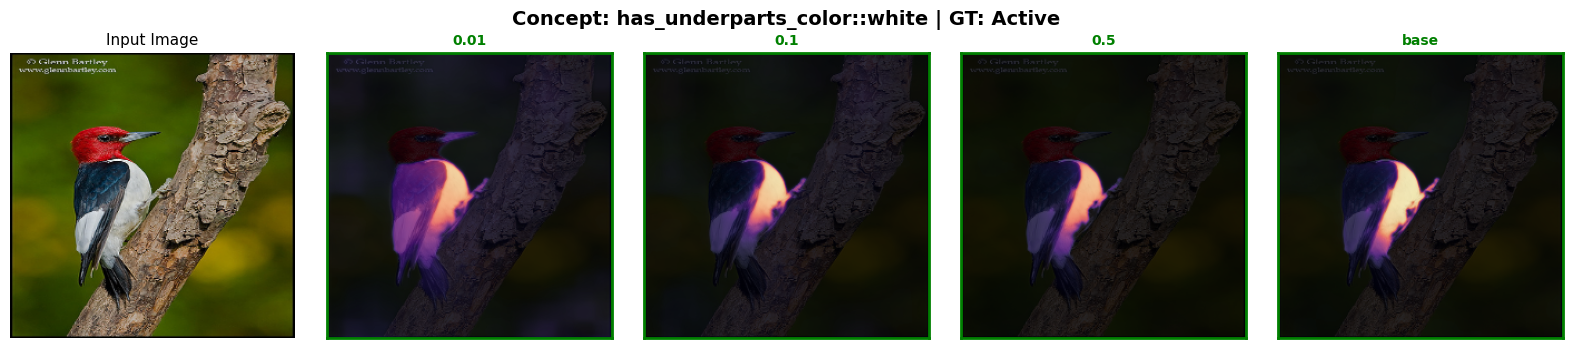

In [109]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions,
    model_names=header,
    concept_id=20,
    concept_names=train_dataset_cub.concepts.to_list(),
    gt_vector=batch.concepts,
    images=batch.images,
    batch_idx=1,
    alpha=0.8
)

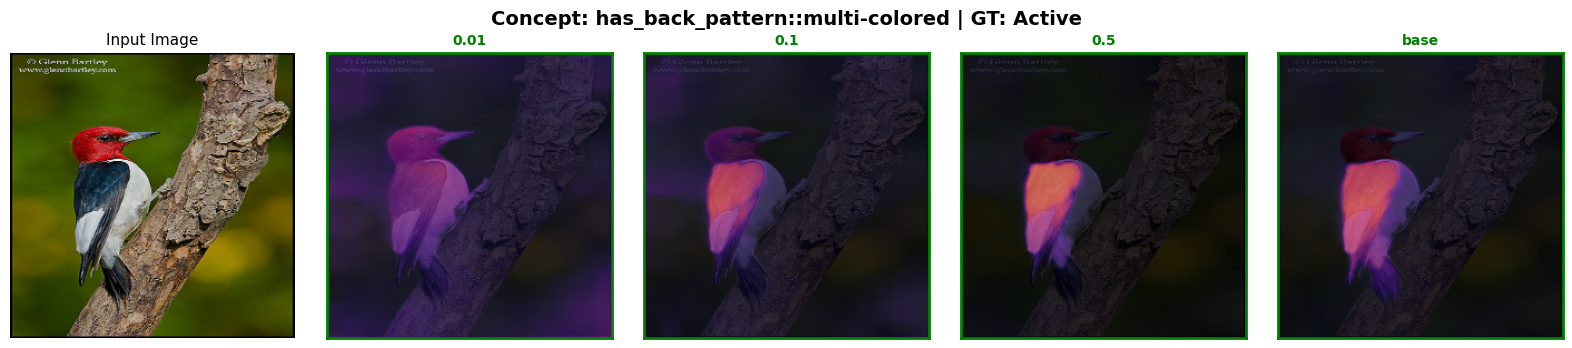

In [110]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions,
    model_names=header,
    concept_id=85,
    concept_names=train_dataset_cub.concepts.to_list(),
    gt_vector=batch.concepts,
    images=batch.images,
    batch_idx=1,
    alpha=0.8
)

In [ ]:
import pickle

import numpy as np

with open("aff_preds.pkl", mode='wb') as f:
    pickle.dump([pred.segmentation_module.mask_logits for pred in results], f)

NameError: name 'batch' is not defined

In [ ]:
run_ids

['9lexo76a', 'c0ldpb7v', 'msu693b8']

In [ ]:
def load_and_predict(run_ids:list[str], epochs:list[int], datasets:list[str], batch:Batch,):

    predictions: list[ExtendedCBMOutput] = [] 
    for run_id, epoch, dataset in tqdm(zip(run_ids, epochs, datasets)):
    
        model = init_from_checkpoint(run_id=run_id, epoch=epoch, dataset=dataset.lower(), device=device)

        pred: ExtendedCBMOutput = model(batch.images)
        predictions.append(pred)

    return predictions

# Test Results Affinity

In [2]:
import pandas as pd
import numpy as np

TEST_RESULTS_PATH_AFF = 'thesis-figures/extended_cbm/results/2_test_metrics_aab-aff.parquet'

test_results = pd.read_parquet(TEST_RESULTS_PATH_AFF)

In [3]:
test_results

,run_id,Total Loss,Mean Dice,Mean IoU,Concept Activations $F_1$-Score,Precision Concepts,Recall Concepts,Concept Accuracy,Label $F_1$-Score,Label Accuracy,Foreground Dice,Concept Module,Segmentation Module,Dataset,Runtime,epoch,dataset
0,9lexo76a,0.0,0.652478,0.636961,0.569770,0.473628,0.739093,0.767225,0.006904,0.006904,0.261898,NaN,Upscaled MultiLayer,None,None,23.0,CUB_112
0,c0ldpb7v,0.0,0.641994,0.627769,0.568304,0.473122,0.737279,0.764960,0.006904,0.006904,0.226417,NaN,Upscaled MultiLayer,None,None,23.0,CUB_112
0,msu693b8,0.0,0.633281,0.621856,0.565622,0.474638,0.725253,0.763713,0.005868,0.005868,0.178984,NaN,Upscaled MultiLayer,None,None,15.0,CUB_112


In [7]:
print(test_results[["Recall Concepts", "Precision Concepts", "Mean IoU", "Foreground Dice", "Concept Activations $F_1$-Score", "Mean Dice", "Concept Accuracy", "run_id"]].to_latex())

\begin{tabular}{lrrrrrrrl}
\toprule
 & Recall Concepts & Precision Concepts & Mean IoU & Foreground Dice & Concept Activations $F_1$-Score & Mean Dice & Concept Accuracy & run_id \\
\midrule
0 & 0.739093 & 0.473628 & 0.636961 & 0.261898 & 0.569770 & 0.652478 & 0.767225 & 9lexo76a \\
0 & 0.737279 & 0.473122 & 0.627769 & 0.226417 & 0.568304 & 0.641994 & 0.764960 & c0ldpb7v \\
0 & 0.725253 & 0.474638 & 0.621856 & 0.178984 & 0.565622 & 0.633281 & 0.763713 & msu693b8 \\
\bottomrule
\end{tabular}



# Indepentent 

In [85]:
run_id = '17m6p70g'

In [86]:
val_results = create_summary_table(val_results_raw, filter_tag=["aab-soft-bce"], reference_measure="Foreground-Dice")

val_results[val_results['run_id']==run_id]['epoch']
epoch = 15


Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet


In [36]:
train_dataset_cub, val_dataset_cub, test_dataset_cub, _, _, _ = get_datasets(dataset_name='CUB_112', 
                                                        root_dir='/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets', 
                                                        img_size=256, 
                                                        use_soft_labels=False, concept_masks_scale=None,
                                                        attr_level='image')

train_loader_cub, val_loader_cub, test_loader_cub = get_dataloader(batch_size=4, num_workers=6, 
                                                       train_dataset=train_dataset_cub, val_dataset=val_dataset_cub, 
                                                       test_dataset=test_dataset_cub)

In [37]:
model = init_from_checkpoint(
    run_id=run_id,
    epoch=epoch,
    dataset='cub_112',
    device=device
)

Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main


# Create Concept Predictions

In [49]:
concept_values = []

for batch in tqdm(val_loader_cub):
    batch:Batch
    batch = batch.to(device)

    prediction: ExtendedCBMOutput = model(batch.images)

    concept_values.append((prediction.concept_module.concept_logits.detach().cpu(), batch.labels.cpu()))

    

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]


In [50]:
import pickle

with open(f'independent_cbm_{run_id}_val.pkl', mode='wb') as f:
    pickle.dump(concept_values, f)

# Training

In [4]:
import pickle

import torch
import torch.nn as nn

from utils.loss import CELossOneHot


In [88]:
with open(f'independent_cbm_{run_id}.pkl', mode='rb') as f:
    train_data:list[tuple[torch.Tensor, torch.Tensor]] = pickle.load(f)

with open(f'independent_cbm_{run_id}_val.pkl', mode='rb') as f:
    val_data:list[tuple[torch.Tensor, torch.Tensor]] = pickle.load(f)

print(len(train_data), len(val_data))

1199 300


In [5]:
from torch.utils.data import DataLoader, TensorDataset


def make_dataloader(data):
    xs = torch.cat([x for x, _ in data], dim=0)  # [N, C]
    ys = torch.cat([y for _, y in data], dim=0)  # [N, K]
    
    print(xs.shape)  # z.B. [N, C]
    
    dataset = TensorDataset(xs, ys)
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    return loader

train_loader = make_dataloader(train_data)
val_loader = make_dataloader(val_data)

NameError: name 'train_data' is not defined

In [6]:
import torch
from sklearn.metrics import f1_score


def evaluate(
    model_linear: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
):

    model.eval()
    model_linear.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for concept_logits, labels in tqdm(dataloader):

            concept_logits = concept_logits.to(device)
            labels = labels.to(device)

            # Linear classifier
            label_logits = model_linear(concept_logits)

            # ---- Predictions ----
            preds = torch.argmax(label_logits, dim=1)

            targets = torch.argmax(labels, dim=1)
            
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    # ---- Metrics ----
    acc = (all_preds == all_targets).float().mean().item()
    f1 = f1_score(
        all_targets.numpy(),
        all_preds.numpy(),
        average="macro"
    )

    return {
        "accuracy": acc,
        "macro_f1": f1
    }

In [7]:
def train_one_epoch(
    linear_model: nn.Module,
    data: list[tuple[torch.Tensor, torch.Tensor]],
    epoch: int,
):

    linear_model.train()
    pbar = tqdm(data)
    linear_model = linear_model.to(device)

    for concept_logits, labels in pbar:

        optimizer.zero_grad()

        concept_logits = concept_logits.to(device)
        labels = labels.to(device)

        pred = linear_model(concept_logits)

        loss = criterion(pred, labels)

        loss.backward()
        optimizer.step()

        pbar.set_description(f"Epoch {epoch} | Loss {loss.item():.4f}")

In [8]:
import os
from pathlib import Path

checkpoint_dir = Path( os.environ['BLOB_DIR'] ) / "checkpoints"

In [93]:
model_linear = nn.Linear(112, 200).to(device)

model = init_from_checkpoint(
    run_id=run_id,
    epoch=epoch,
    dataset='cub_112',
    device=device
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = CELossOneHot()
optimizer = torch.optim.AdamW(model_linear.parameters())

Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main


In [94]:
epochs = 50

for epoch in range(epochs):
    train_one_epoch(linear_model=model_linear, data=train_loader, epoch=epoch)
    metrics = evaluate(
        model_linear=model_linear,
        dataloader=val_loader,
        device=device
    )

    torch.save(
        {
            "epoch": epoch,
            "model_linear_state_dict": model_linear.state_dict(),
            "metrics": metrics,
        },
        checkpoint_dir / f"extended_cbm_{run_id}_{epoch}.pth"
    )
    print(metrics)

Epoch 0 | Loss 3.5433: 100%|██████████| 75/75 [00:00<00:00, 108.50it/s]
100%|██████████| 19/19 [00:00<00:00, 1689.92it/s]


{'accuracy': 0.2963272035121918, 'macro_f1': 0.2513465289952386}


Epoch 1 | Loss 2.6880: 100%|██████████| 75/75 [00:00<00:00, 791.21it/s]
100%|██████████| 19/19 [00:00<00:00, 1986.09it/s]


{'accuracy': 0.5175291895866394, 'macro_f1': 0.4894987305111347}


Epoch 2 | Loss 2.2479: 100%|██████████| 75/75 [00:00<00:00, 794.25it/s]
100%|██████████| 19/19 [00:00<00:00, 2005.48it/s]


...

{'accuracy': 0.7587646245956421, 'macro_f1': 0.7589471537234695}


Epoch 48 | Loss 0.6026: 100%|██████████| 75/75 [00:00<00:00, 611.37it/s]
100%|██████████| 19/19 [00:00<00:00, 1958.03it/s]


{'accuracy': 0.7579298615455627, 'macro_f1': 0.7583024230241722}


Epoch 49 | Loss 0.5946: 100%|██████████| 75/75 [00:00<00:00, 619.56it/s]
100%|██████████| 19/19 [00:00<00:00, 1942.38it/s]


{'accuracy': 0.7579298615455627, 'macro_f1': 0.7583243528487337}


--- Bestes Ergebnis bei Sequential: {'accuracy': 0.7587646245956421, 'macro_f1': 0.7589471537234695} ---

# FunnyBirds

In [9]:
run_id = 'dwxi34vh'
epoch = 23

In [11]:
train_dataset_fb, val_dataset_fb, test_dataset_cub, _, _, _ = get_datasets(dataset_name='FunnyBirds', 
                                                        root_dir='/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets', 
                                                        img_size=256, 
                                                        use_soft_labels=False, concept_masks_scale=None,
                                                        attr_level='image')

train_loader_fb, val_loader_fb, test_loader_cub = get_dataloader(batch_size=4, num_workers=14, 
                                                       train_dataset=train_dataset_fb, val_dataset=val_dataset_fb, 
                                                       test_dataset=test_dataset_cub)

In [16]:
from architecture.extended_cbm import CBMWrapper, get_cbm_wrapper


def init_from_checkpoint(run_id: str, epoch:int, dataset: str, device: torch.device | str) -> CBMWrapper:
    checkpoint_path = f"/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/blobs/checkpoints/cbm_anyup_dinov3_{dataset}_run_{run_id}_epoch{epoch}.pth"
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    config = checkpoint['config']

    upsampler_name = config['architecture']['upsampler']
    unified_name = config['architecture']['unified_model']
    segmentation_module_name = config['architecture']['segmentation_module']
    classification_module_name = config['architecture']['classification_module']
    n_classes = 200 if dataset == 'cub_112' else 50
    n_concepts = config['n_concepts'] if 'n_concepts' in config.keys() else 26
    top_k_percent = config['hyperparameters']['top_k_percent']
    concept_module_name = config['architecture']['concept_module']
    dino_ckpt_segdino = 'dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'
    img_size = 256

    

    model = get_cbm_wrapper(encoder_name='dinov3', upsampler_name=upsampler_name, freeze_encoder=True,
        freeze_upsampler=True, unified_name=unified_name, 
        segmentation_module_name=segmentation_module_name, 
        classification_module_name=classification_module_name,
        n_classes=n_classes, 
        n_concepts=n_concepts, 
        top_k_percent=top_k_percent,
        concept_module_name=concept_module_name, 
        dino_ckpt_segdino=dino_ckpt_segdino, 
        img_size=img_size
        )
    
    missing, unexpected = model.load_state_dict(
        checkpoint['model_state_dict'],
        strict=True
    )
    return model.to(device)

In [17]:
device = 'cuda'
model = init_from_checkpoint(
    run_id=run_id,
    epoch=epoch,
    dataset='funnybirds',
    device=device
)

Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main


# Create Concept Predictions

In [20]:
concept_values = []

model.eval()

for batch in tqdm(val_loader_fb):
    batch:Batch
    batch = batch.to(device)

    prediction: ExtendedCBMOutput = model(batch.images)

    concept_values.append((prediction.concept_module.concept_logits.detach().cpu(), batch.labels.cpu()))

    

100%|██████████| 38/38 [00:08<00:00,  4.67it/s]


In [21]:
import pickle

with open(f'independent_cbm_{run_id}_val.pkl', mode='wb') as f:
    pickle.dump(concept_values, f)

In [ ]:
concept_values = []

model.eval()

for batch in tqdm(train_loader_fb):
    batch:Batch
    batch = batch.to(device)

    prediction: ExtendedCBMOutput = model(batch.images)

    concept_values.append((prediction.concept_module.concept_logits.detach().cpu(), batch.labels.cpu()))

    

  0%|          | 0/12500 [00:00<?, ?it/s]

 21%|██        | 2599/12500 [06:52<24:51,  6.64it/s]  

In [ ]:
import pickle

with open(f'independent_cbm_{run_id}_train.pkl', mode='wb') as f:
    pickle.dump(concept_values, f)

# Training

In [ ]:
with open(f'independent_cbm_{run_id}.pkl', mode='rb') as f:
    train_data:list[tuple[torch.Tensor, torch.Tensor]] = pickle.load(f)

with open(f'independent_cbm_{run_id}_val.pkl', mode='rb') as f:
    val_data:list[tuple[torch.Tensor, torch.Tensor]] = pickle.load(f)

print(len(train_data), len(val_data))

In [ ]:
train_loader = make_dataloader(train_data)
val_loader = make_dataloader(val_data)

In [ ]:
model_linear = nn.Linear(26, 50).to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = CELossOneHot()
optimizer = torch.optim.AdamW(model_linear.parameters())

Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main


In [ ]:
epochs = 50

for epoch in range(epochs):
    train_one_epoch(linear_model=model_linear, data=train_loader_fb, epoch=epoch)
    metrics = evaluate(
        model_linear=model_linear,
        dataloader=val_loader,
        device=device
    )

    torch.save(
        {
            "epoch": epoch,
            "model_linear_state_dict": model_linear.state_dict(),
            "metrics": metrics,
        },
        checkpoint_dir / f"extended_cbm_{run_id}_{epoch}.pth"
    )
    print(metrics)